In [ ]:
import numpy as np
import pandas as pd

In [ ]:
main_dataset = pd.read_csv('main_dataset.csv')
sev_dataset = main_dataset[main_dataset["CLAIM_NB"] > 0].copy()


In [ ]:
#punkt 6

main_dataset["BASE_ACTUARIAL_COST"] = (
    main_dataset["PRED_FREQ"] * main_dataset["PRED_SEV"] * main_dataset["EXPOSURE"]
)

main_dataset["FULL_ACTUARIAL_COST"] = (
    main_dataset["BASE_ACTUARIAL_COST"] * 1.20
)

main_dataset["VARIABLE_COST"] = (
    main_dataset["FULL_ACTUARIAL_COST"] * (1 / 0.7 - 1)
)

In [ ]:
#punkt 7

main_dataset["PREMIUM"] = (
    (main_dataset["FULL_ACTUARIAL_COST"] + main_dataset["VARIABLE_COST"]) / 0.95
)

main_dataset["MARGIN"] = (
    main_dataset["PREMIUM"]
    - main_dataset["FULL_ACTUARIAL_COST"]
    - main_dataset["VARIABLE_COST"]
)

main_dataset["MARGIN_RATIO"] = (
    main_dataset["MARGIN"] / main_dataset["PREMIUM"]
)

In [ ]:
main_dataset[['BASE_ACTUARIAL_COST', 'FULL_ACTUARIAL_COST', 'PREMIUM', 'MARGIN']].describe()

,BASE_ACTUARIAL_COST,FULL_ACTUARIAL_COST,PREMIUM,MARGIN
count,668897.000000,668897.000000,668897.000000,668897.000000
mean,69.857730,83.829276,126.059061,6.302953
std,54.775664,65.730797,98.843304,4.942165
min,0.147728,0.177274,0.266577,0.013329
25%,22.908858,27.490629,41.339292,2.066965
50%,64.614445,77.537334,116.597495,5.829875
75%,105.160933,126.193120,189.764090,9.488205
max,754.439035,905.326842,1361.393748,68.069687


In [ ]:
# #zapis

main_dataset.to_csv(
    "main_dataset_with_predictions.csv",
    index=False,
    sep=";",
    decimal=",",
    encoding="utf-8"
)

In [ ]:
total_premium = main_dataset["PREMIUM"].sum()
total_claims = main_dataset["CLAIM_TOTAL_AMOUNT"].sum()
realized_profit = total_premium - total_claims
expected_profit = main_dataset["MARGIN"].sum()
loss_ratio = total_claims / total_premium

print(f"Suma składek:      {total_premium:,.2f}".replace(',', ' '))
print(f"Suma wypłaconych odszkodowań:      {total_claims:,.2f}".replace(',', ' '))
print(f"Rzeczywisty zysk (Realized Profit): {realized_profit:,.2f}".replace(',', ' '))
print(f"Oczekiwany zysk (Expected Margin):  {expected_profit:,.2f}".replace(',', ' '))
print(f"Loss Ratio (Szkodowość):            {loss_ratio:.2%}")

Suma składek:      84 320 527.96
Suma wypłaconych odszkodowań:      59 909 216.50
Rzeczywisty zysk (Realized Profit): 24 411 311.46
Oczekiwany zysk (Expected Margin):  4 216 026.40
Loss Ratio (Szkodowość):            71.05%


In [ ]:
age_stats = main_dataset.groupby("DRIV_AGE_BIN", observed=False).agg({
    "PREMIUM": ["mean", "sum"],
    "CLAIM_TOTAL_AMOUNT": "sum",
    "CLAIM_NB": "sum",
    "EXPOSURE": ["sum", "count"]
}).reset_index()

age_stats.columns = [
    "DRIV_AGE_BIN",
    "AVG_PREMIUM",
    "TOTAL_PREMIUM",
    "TOTAL_CLAIMS_COST",
    "CLAIM_COUNT",
    "TOTAL_EXPOSURE",
    "POLICY_COUNT"
]

age_stats["LOSS_RATIO"] = age_stats["TOTAL_CLAIMS_COST"] / age_stats["TOTAL_PREMIUM"]
age_stats["FREQUENCY"] = age_stats["CLAIM_COUNT"] / age_stats["TOTAL_EXPOSURE"]

display_cols = ["DRIV_AGE_BIN", "POLICY_COUNT", "AVG_PREMIUM", "LOSS_RATIO", "FREQUENCY"]

display_df = age_stats[display_cols].copy()
display_df["LOSS_RATIO"] = display_df["LOSS_RATIO"].apply(lambda x: f"{x:.2%}")
display_df["AVG_PREMIUM"] = display_df["AVG_PREMIUM"].apply(lambda x: f"{x:.2f}")
display_df["FREQUENCY"] = display_df["FREQUENCY"].apply(lambda x: f"{x:.4f}")

print(display_df)

  DRIV_AGE_BIN  POLICY_COUNT AVG_PREMIUM LOSS_RATIO FREQUENCY
0        18-22         15562      312.70    204.20%    0.1932
1        23-30         82698      128.95     62.94%    0.0912
2        31-40        159947      113.31     65.62%    0.0697
3        41-50        154708      122.75     57.72%    0.0763
4        51-60        126419      120.37     60.64%    0.0701
5        61-70         59630      109.91     66.41%    0.0627
6          70+         36489      150.97     73.71%    0.0611


/tmp/ipython-input-4062461141.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


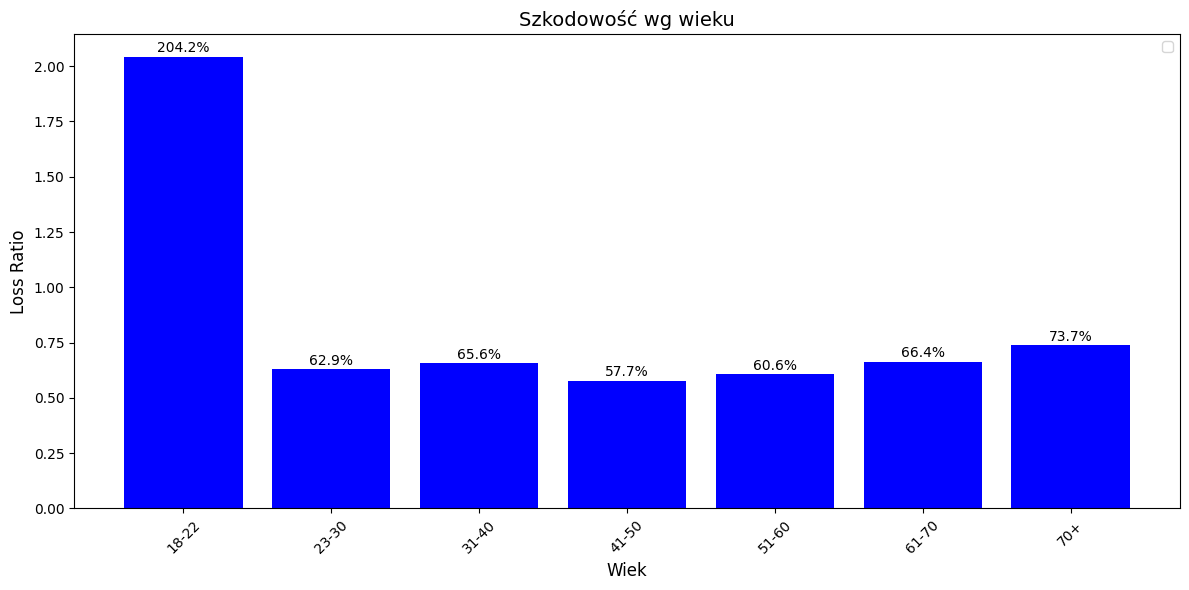

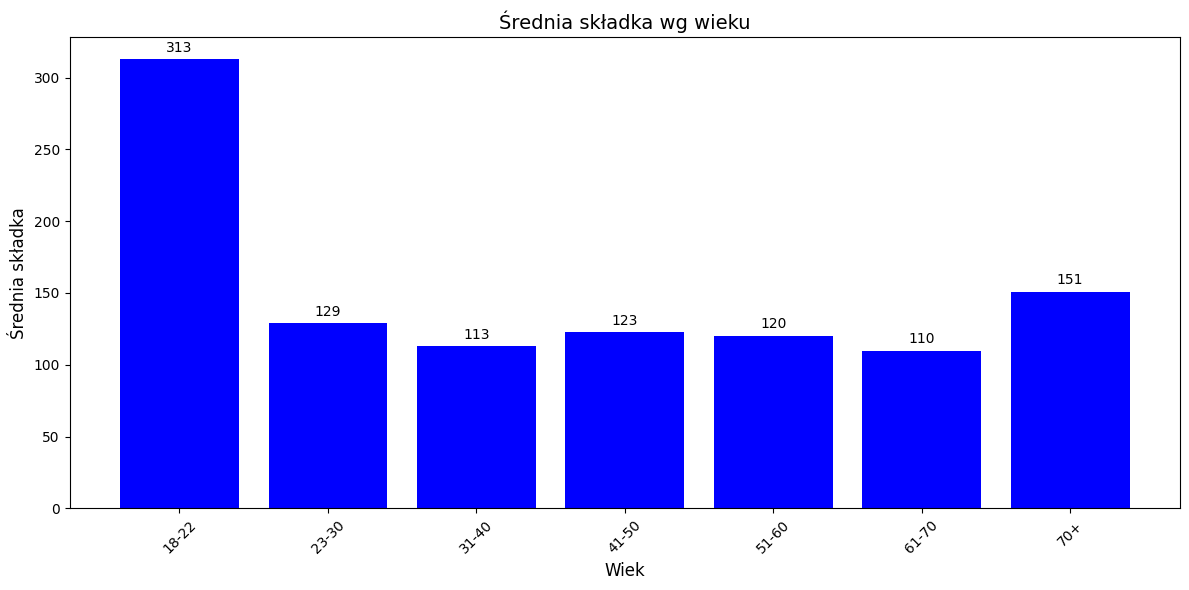

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    age_stats["DRIV_AGE_BIN"],
    age_stats["LOSS_RATIO"],
    color="blue"
)

plt.title("Szkodowość wg wieku", fontsize=14)
plt.xlabel("Wiek", fontsize=12)
plt.ylabel("Loss Ratio", fontsize=12)


for idx, val in enumerate(age_stats["LOSS_RATIO"]):
    if pd.notnull(val):
        plt.text(idx, val + 0.02, f"{val:.1%}", ha="center", fontsize=10)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

plt.bar(
    age_stats["DRIV_AGE_BIN"],
    age_stats["AVG_PREMIUM"],
    color="blue"
)

plt.title("Średnia składka wg wieku", fontsize=14)
plt.xlabel("Wiek", fontsize=12)
plt.ylabel("Średnia składka", fontsize=12)

for idx, val in enumerate(age_stats["AVG_PREMIUM"]):
    if pd.notnull(val):
        plt.text(idx, val + 5, f"{val:.0f}", ha="center", fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

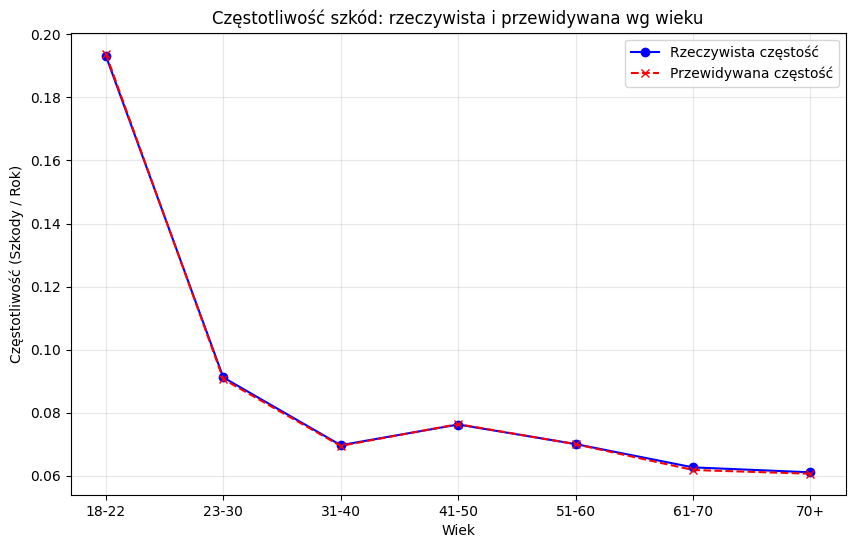

In [ ]:
main_dataset["PRED_CLAIM_NB"] = main_dataset["PRED_FREQ"] * main_dataset["EXPOSURE"]

age_summary = main_dataset.groupby("DRIV_AGE_BIN", observed=False).agg({
    "CLAIM_NB": "sum",
    "PRED_CLAIM_NB": "sum",
    "EXPOSURE": "sum"
}).reset_index()

age_summary["OBS_FREQ_MEAN"] = age_summary["CLAIM_NB"] / age_summary["EXPOSURE"]
age_summary["PRED_FREQ_MEAN"] = age_summary["PRED_CLAIM_NB"] / age_summary["EXPOSURE"]

plt.figure(figsize=(10, 6))

x_labels = age_summary["DRIV_AGE_BIN"].astype(str)

plt.plot(x_labels, age_summary["OBS_FREQ_MEAN"], marker='o', label='Rzeczywista częstość', color='blue')
plt.plot(x_labels, age_summary["PRED_FREQ_MEAN"], marker='x', linestyle='--', label='Przewidywana częstość', color='red')

plt.title("Częstotliwość szkód: rzeczywista i przewidywana wg wieku")
plt.xlabel("Wiek")
plt.ylabel("Częstotliwość (Szkody / Rok)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

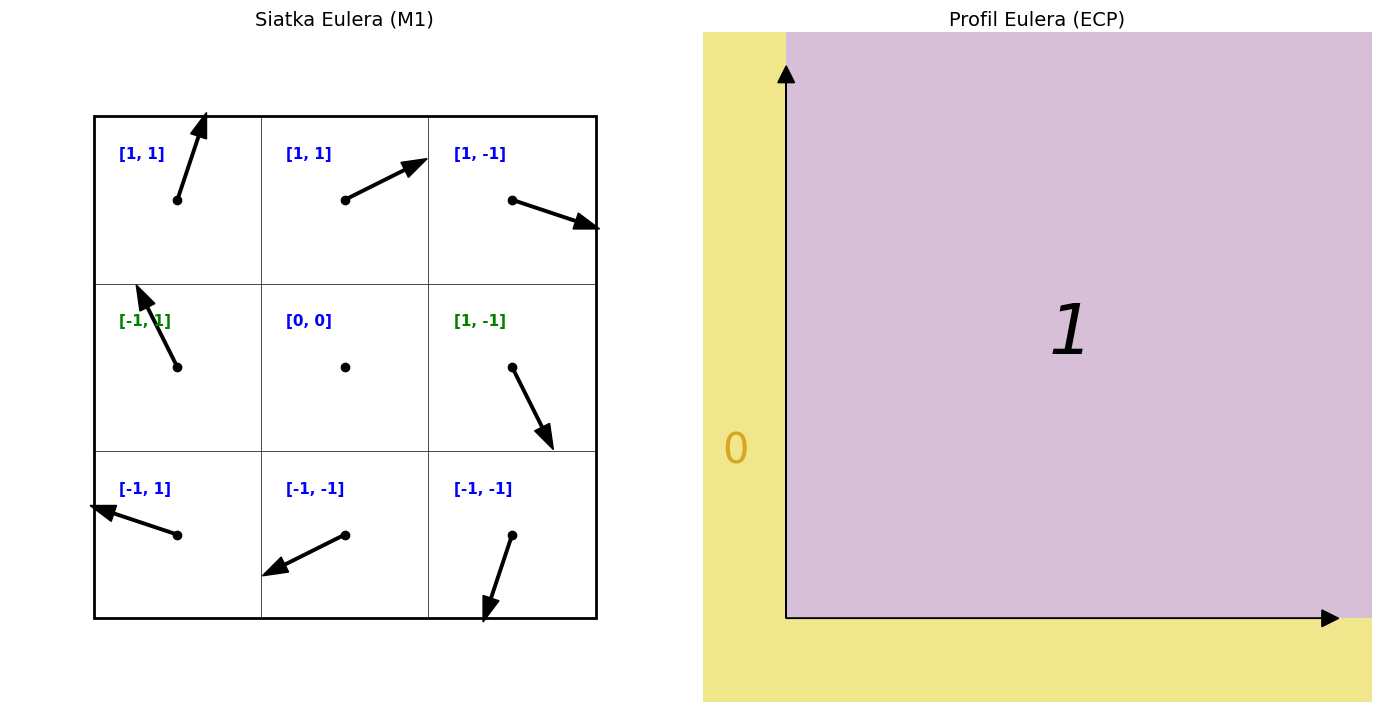

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Definicja macierzy M1 (Unstable Focus)
M1 = np.array([[2.0, 4.0],
               [-4.0, 2.0]])

# Punkty siatki
x_vals = [-1, 0, 1]
y_vals = [-1, 0, 1]

# Tworzenie rysunku z dwoma panelami
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# --- RYSUNEK 1: SIATKA WEKTOROWA ---

# Rysowanie ramki siatki
rect = patches.Rectangle((-1.5, -1.5), 3, 3, linewidth=2, edgecolor='black', facecolor='none')
ax1.add_patch(rect)
# Linie podziału
ax1.plot([-1.5, 1.5], [-0.5, -0.5], 'k-', lw=0.5)
ax1.plot([-1.5, 1.5], [0.5, 0.5], 'k-', lw=0.5)
ax1.plot([-0.5, -0.5], [-1.5, 1.5], 'k-', lw=0.5)
ax1.plot([0.5, 0.5], [-1.5, 1.5], 'k-', lw=0.5)

# Pętla po punktach siatki
for y in reversed(y_vals):
    for x in x_vals:
        # Obliczenie wektora
        vec = M1 @ np.array([x, y])
        dx, dy = vec[0], vec[1]

        # Obliczenie znaków (kodu)
        sx = int(np.sign(dx))
        sy = int(np.sign(dy))
        label_text = f"[{sx}, {sy}]"

        # Logika kolorów etykiet (wzór z notatki: góra/dół niebieskie, boki zielone)
        if y in [1, -1]:
            color = 'blue'
        elif x in [-1, 1]:
            color = 'green'
        else:
            color = 'blue' # Środek domyślnie

        # Rysowanie punktu
        ax1.plot(x, y, 'ko', markersize=6)

        # Rysowanie CZARNEJ strzałki
        if not (dx == 0 and dy == 0):
            norm = np.sqrt(dx**2 + dy**2)
            scale = 0.4
            ax1.arrow(x, y, (dx/norm)*scale, (dy/norm)*scale,
                      head_width=0.1, head_length=0.15, fc='black', ec='black', width=0.015)

        # Rysowanie KOLOROWEJ etykiety
        ax1.text(x - 0.35, y + 0.25, label_text, color=color, fontsize=11, fontweight='bold')

ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title("Siatka Eulera (M1)", fontsize=14)

# --- RYSUNEK 2: PROFIL ŻÓŁTO-FIOLETOWY ---

# Ustawienie żółtego tła (wartość 0)
ax2.set_facecolor('#F0E68C') # Kolor Khaki/Żółty
ax2.add_patch(patches.Rectangle((-3, -3), 6, 6, color='#F0E68C')) # Tło jako prostokąt

# Osie współrzędnych
ax2.arrow(-1.5, -1.5, 3.2, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', zorder=10)
ax2.arrow(-1.5, -1.5, 0, 3.2, head_width=0.1, head_length=0.1, fc='black', ec='black', zorder=10)

# Fioletowy obszar (wartość 1) - analogicznie do notatki
# Rysujemy duży fioletowy kwadrat symbolizujący obszar gdzie chi = 1
purple_rect = patches.Rectangle((-1.5, -1.5), 3.5, 3.5, linewidth=0, facecolor='#D8BFD8', alpha=1.0) # Kolor Thistle/Fiolet
ax2.add_patch(purple_rect)

# Dodanie cyfry 1
ax2.text(0.2, 0.2, "1", fontsize=50, color='black', ha='center', va='center', fontstyle='italic')

# Dodanie cyfry 0 na żółtym tle
ax2.text(-1.8, -0.5, "0", fontsize=30, color='#DAA520', ha='center', va='center')

ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title("Profil Eulera (ECP)", fontsize=14)

plt.tight_layout()
plt.savefig('zadanie_M1_wizualizacja.png')
plt.show()